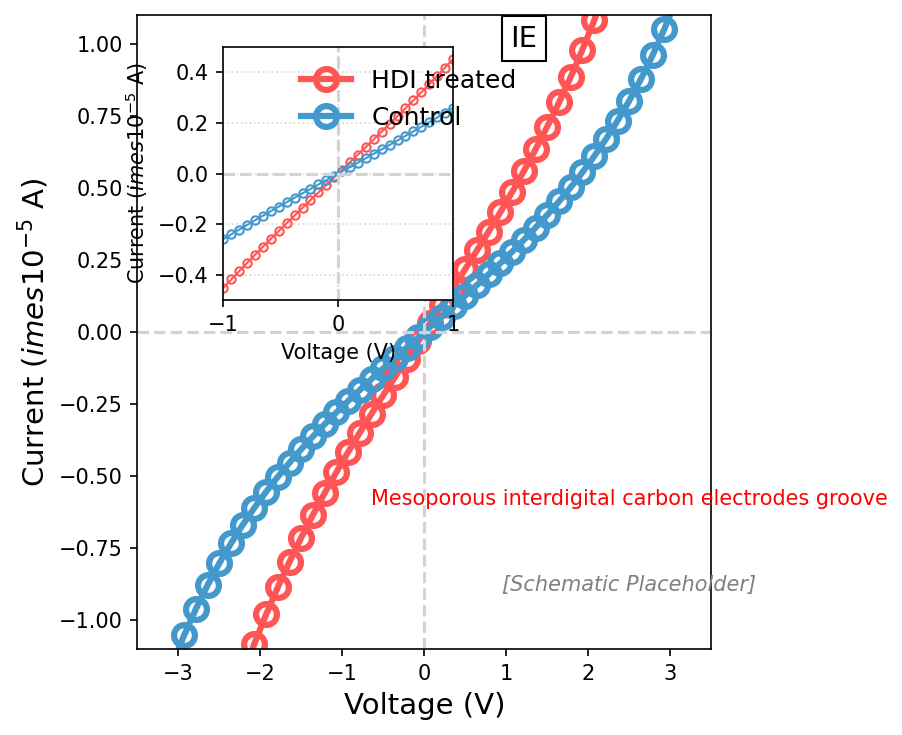

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
voltage = np.linspace(-3.5, 3.5, 50)

# Control (Blue) - Standard Resistor-like but slightly non-linear
# I = V / R
control_current = (voltage / 5.0) * 1e-5
# Add slight curvature
control_current += 0.05e-5 * np.sinh(voltage)

# HDI Treated (Red) - Higher conductivity
hdi_current = (voltage / 3.0) * 1e-5
hdi_current += 0.1e-5 * np.sinh(voltage)

# Zoom Data (Voltage -1 to 1)
v_zoom = np.linspace(-1, 1, 30)
c_zoom = (v_zoom / 5.0) * 1e-5 + 0.05e-5 * np.sinh(v_zoom)
h_zoom = (v_zoom / 3.0) * 1e-5 + 0.1e-5 * np.sinh(v_zoom)


# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Main Plot
# Markers: Open circles
# Ticks formatting to show x10^-5?
# Or just divide data by 1e-5 and label axis as such.
# Let's re-plot with scaled data for simplicity
hdi_scaled = hdi_current / 1e-5
ctrl_scaled = control_current / 1e-5

ax.plot(voltage, hdi_scaled, 'o-', color='#FF5555', mfc='none', mew=3, markersize=10, lw=3, label='HDI treated')
ax.plot(voltage, ctrl_scaled, 'o-', color='#4499CC', mfc='none', mew=3, markersize=10, lw=3, label='Control')

# Styling
ax.set_xlabel('Voltage (V)', fontsize=14)
ax.set_ylabel(r'Current ($	imes 10^{-5}$ A)', fontsize=14)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-1.1, 1.1)

# Dashed zero lines
ax.axhline(0, color='lightgray', linestyle='--')
ax.axvline(0, color='lightgray', linestyle='--')

# Legend
ax.legend(frameon=False, loc='upper right', fontsize=12, bbox_to_anchor=(0.7, 0.95))
ax.text(0.65, 0.95, 'IE', transform=ax.transAxes, fontsize=14, bbox=dict(facecolor='none', edgecolor='black'))

# Inset (Zoom)
ax_ins = ax.inset_axes([0.15, 0.55, 0.4, 0.4])
ax_ins.plot(v_zoom, h_zoom/1e-5, 'o-', color='#FF5555', mfc='none', mew=1, markersize=4, lw=1)
ax_ins.plot(v_zoom, c_zoom/1e-5, 'o-', color='#4499CC', mfc='none', mew=1, markersize=4, lw=1)
ax_ins.set_xlim(-1, 1)
ax_ins.set_ylim(-0.5, 0.5)
ax_ins.set_xlabel('Voltage (V)', fontsize=10)
ax_ins.set_ylabel(r'Current ($	imes 10^{-5}$ A)', fontsize=10)
ax_ins.grid(True, linestyle=':', alpha=0.5)
ax_ins.axhline(0, color='lightgray', linestyle='--')
ax_ins.axvline(0, color='lightgray', linestyle='--')

# Schematic placeholder text
ax.text(2.5, -0.6, 'Mesoporous interdigital carbon electrodes groove', color='red', fontsize=10, ha='center')
ax.text(2.5, -0.9, '[Schematic Placeholder]', color='gray', fontsize=10, ha='center', style='italic')

plt.tight_layout()
plt.show()

